## Ejemplo básico de una red neuronal para clasificación de imágenes

## Importación de las librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

## Carga de los datos
Vamos a utilizar el propio dataset que viene precargado en Keras:
https://keras.io/api/datasets/fashion_mnist/

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Exploración y visualización de los datos
Utilizamos len, shape, e imshow para explorar y ver con qué estamos trabajando
Pistas: adimensionalizar las imágenes (intensidad de tono de pixel) y crear una lista con los nombres de las clases.

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
len(train_labels)

60000

In [ ]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

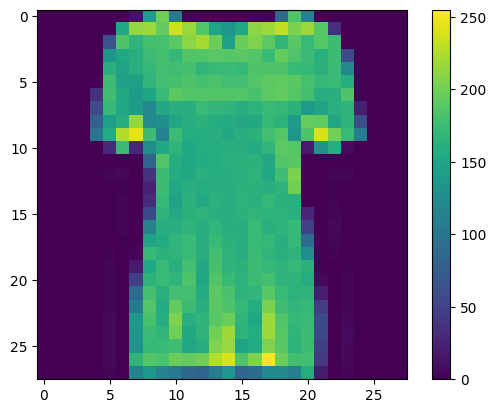

In [ ]:
plt.figure()
plt.imshow(train_images[10])
plt.colorbar()


In [ ]:
train_images = train_images/255.0
test_images = test_images/255.0

<function matplotlib.pyplot.show(close=None, block=None)>

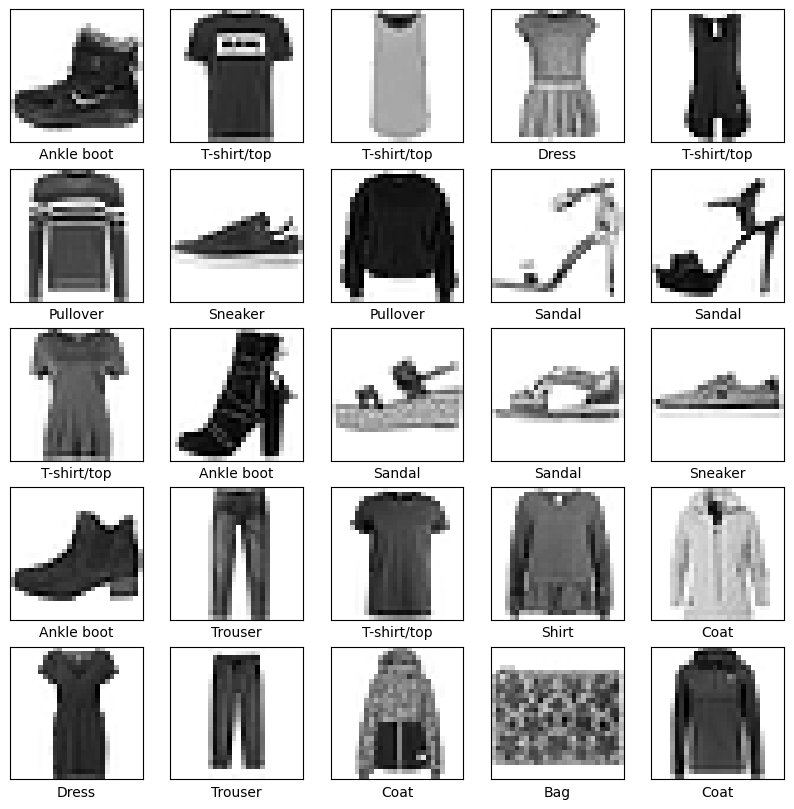

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(train_images[i], cmap = plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])

# El método show no es necesario en colab
plt.show

## Construcción del modelo
Llamamos a la clase Sequential y usamos layers para crear las capas. Con Dense, se crean las capas de red neuronal. Utilizaremos las funciones de activación ReLu en las capas internas y Softmax en la de salida.

Pista: Flatten crea una capa que reduce a 1 la dimensión del array de las imágenes

In [ ]:
model = keras.Sequential([
   keras.layers.Flatten(input_shape = (28,28)),
   keras.layers.Dense(128, activation='relu'),
   keras.layers.Dense(10,activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Parámetros del entrenamiento
El método compile nos permite configurar el optimizador, función de coste,etc. En este caso, vamos a recurrir al optimizador Adam, y la función de coste sparse_categorical_crossentropy.

In [ ]:
model.compile(optimizer= 'Adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

## Entrenamiento del modelo
Utilizamos la función fit para el entrenamiento de la DNN. Tenemos que pasar como argumentos los valores de entrada, los de salida (las etiquetas) y el número de iteraciones o epochs.

In [ ]:
model.fit(train_images,train_labels,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8964 - loss: 0.2794
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8984 - loss: 0.2711
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9064 - loss: 0.2547
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9093 - loss: 0.2510
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9110 - loss: 0.2379
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9154 - loss: 0.2283
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9154 - loss: 0.2222
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9198 - loss: 0.2144
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9229 - loss: 0.2058
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9222 - loss: 0.2051


## Evaluación del modelo
Para evaluar el modelo, recurrimos a la función evaluate y guardamos los valores que nos devuelve, el error o loss, y la precisión o accuracy.

In [ ]:
test_loss,test_acc = model.evaluate(test_images,test_labels)

print('Test accuracy: ', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8856 - loss: 0.3514
Test accuracy:  0.8845999836921692


## Generación del modelo predictivo y pruebas
Con la función predict, generamos la colección de resultados del modelo para nuevos datos de entrada, y podemos analizar su comportamiento.

In [ ]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predictions[5]

array([3.69135620e-07, 9.99999583e-01, 5.42141505e-11, 9.77798109e-09,
       7.77888776e-09, 8.64218271e-20, 1.32215350e-08, 8.03323641e-22,
       1.79912414e-13, 1.37058476e-17], dtype=float32)

In [ ]:
np.argmax(predictions[5])

1

In [ ]:
class_names[1]

'Trouser'

In [ ]:
class_names[test_labels[5]]

'Trouser'

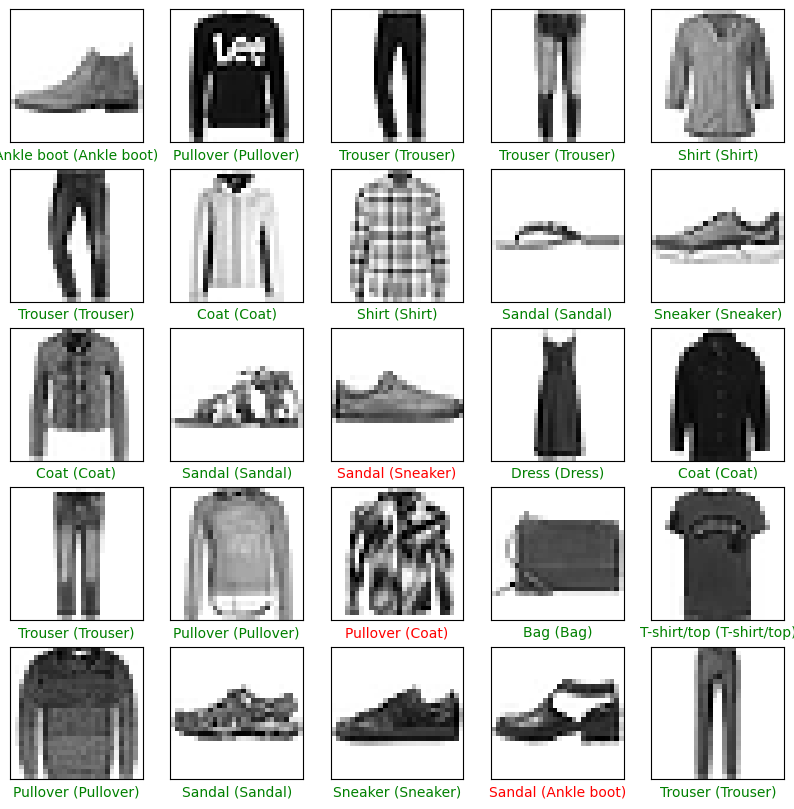

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(test_images[i],cmap=plt.cm.binary)
  predicted_label = np.argmax(predictions[i])
  true_label = test_labels[i]
  if predicted_label == true_label:
    color = 'green'
  else:
    color = 'red'

  plt.xlabel("{} ({})".format(class_names[predicted_label],
                              class_names[true_label]),
                              color=color)

In [ ]:
# MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

In [ ]:
%%shell
jupyter nbconvert --to html /content/Mod3_T3_4_Red_neuronal_profunda_sencilla.ipynb

[NbConvertApp] Converting notebook /content/Mod3_T3_4_Red_neuronal_profunda_sencilla.ipynb to html
[NbConvertApp] Writing 437254 bytes to /content/Mod3_T3_4_Red_neuronal_profunda_sencilla.html
